# CBTN learning lab for multi-modal imaging
## Tumor size assessment over time using volumetric segmentations
#### October 10, 2024

This notebook illustrates how to extract tumor volumetrics to assess changes in tumor size over time. Assuming 3D volumetric segmentations have been generated such as via the `d3b-ped-auto-seg-nnunet` or `brats2024-peds-awssme` deep learning-based segmentation gears, and if necessary manually edited for accuracy.

In [ ]:
import flywheel
import os

your_api_key = 'enter-your-api-key'
fw = flywheel.Client(your_api_key)

In [4]:

fw = flywheel.Client(os.getenv('FW_LAB_API_KEY'))

In [28]:
# get the project container
proj_container = fw.lookup('cbtn-summit/CBTN_proc_data')

# set up a local folder to store the data files in
def maybe_make_dir(dir_path):
    if not os.path.exists(dir_path):
        os.makedirs(dir_path)

local_data_dir = 'data'
maybe_make_dir(local_data_dir)

# loop through all files in the project
# if an edited tumor seg file exists then download it to the local folder
for session in proj_container.sessions.iter():
    sub_label = session.subject.label
    ses_label = session.label
    for acquisition in session.acquisitions.iter():
        for file_ in acquisition.files:
            if ('ManualSegmentation' in file_.name) or \
                ('PredictedSeg' in file_.name):
                local_session_dir = f'{local_data_dir}/{sub_label}/{ses_label}/'
                maybe_make_dir(local_session_dir)
                acquisition.download_file(file_.name, f'{local_session_dir}/{file_.name}')


In [11]:
import nibabel as nib
import numpy as np

# initialize volume calculator
def calculate_whole_tumor_size(seg_filename):
    mask = nib.load(seg_filename).get_fdata()
    mask = np.rint(mask)

    seg_voxels = mask[mask!=0]
    return len(seg_voxels)

    # enhancing_mask = np.logical_and(mask >= 1, mask <= 1)
    # nonenhancing_mask = np.logical_and(mask >= 2, mask <= 2)
    # cyst_mask = np.logical_and(mask >= 3, mask <= 3)
    # edema_mask = np.logical_and(mask >= 4, mask <= 4)
    # wt_mask = np.logical_and(mask >= 1, mask <= 3)


In [31]:
from glob import glob
import pandas as pd

file_list = glob(f'{local_data_dir}/*/*/*.nii.gz')

# initialize our results lists
results = []

for seg_file_path in file_list:
    sub_label = seg_file_path.split('/')[1]
    ses_label = seg_file_path.split('/')[2]
    size_in_vox = calculate_whole_tumor_size(seg_file_path)
    if ('Manual' in seg_file_path):
        results.append([sub_label, ses_label, size_in_vox,'manual'])
    elif ('Predicted' in seg_file_path):
        results.append([sub_label, ses_label, size_in_vox,'model-predicted'])

# convert our list into a pandas dataframe
df = pd.DataFrame(results, columns=['subject','session','tumor_size_vox','seg_type'])



In [32]:
df.head()

,subject,session,tumor_size_vox,seg_type
0,C2479803,6046,14898,model-predicted
1,C2479803,6046,11591,manual
2,C2479803,6681,4065,manual
3,C2479803,6681,0,model-predicted
4,C2479803,6229,164,manual


In [33]:
df['session'] = df['session'].astype(int)
df = df.sort_values(by='session', axis=0).reset_index(drop=True)


In [34]:
df.head()

,subject,session,tumor_size_vox,seg_type
0,C1173420,697,1869,manual
1,C1173420,697,39321,model-predicted
2,C1173420,791,11040,model-predicted
3,C1173420,791,3333,manual
4,C1277724,4762,31371,model-predicted


In [ ]:
from scipy.optimize import curve_fit

# Define the function to fit
def func(x, a, b, c):
    return a * np.exp(-b * x) + c

def curve_fit_(x_data, y_data):
    # Fit the curve
    popt, _ = curve_fit(func, x_data, y_data)
    # Generate x values for the fitted curve
    x_fit = np.linspace(x_data.min(), x_data.max(), 100)
    # Calculate y values for the fitted curve
    y_fit = func(x_fit, *popt)
    return x_fit,y_fit


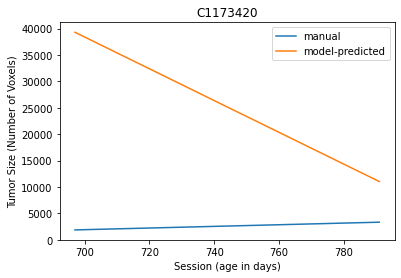

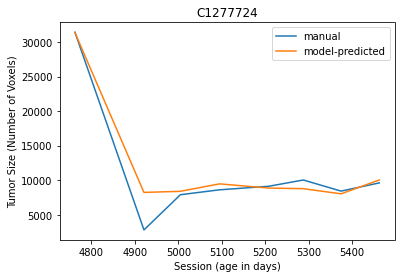

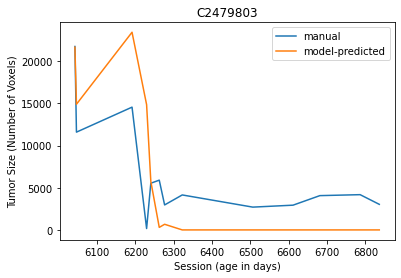

In [51]:
import matplotlib.pyplot as plt

# for each unique subject, plot their tumor volume over time
# separately for manually edited & model-predicted segmentations
for sub in df['subject'].unique().tolist():
    sub_df = df[df['subject']==sub]
    for seg_type in df['seg_type'].unique().tolist():
        seg_df = sub_df[sub_df['seg_type']==seg_type]
        plt.plot(seg_df['session'], seg_df['tumor_size_vox'], label=seg_type)
    plt.xlabel('Session (age in days)')
    plt.ylabel('Tumor Size (Number of Voxels)')
    plt.title(sub)
    plt.legend()
    plt.show()

